# 📊 Netflix Data Visualization Task

In [3]:
# import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
# load dataset
df=pd.read_csv("netflix1.csv")

## Initial Exploration (EDA)

 ### Task 1: Basic Inspection

In [5]:
# Display the first 5 rows.
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [6]:
# Check dataset shape 
df.shape

(8790, 10)

In [7]:
# Check dataset info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8790 non-null   str  
 1   type          8790 non-null   str  
 2   title         8790 non-null   str  
 3   director      8790 non-null   str  
 4   country       8790 non-null   str  
 5   date_added    8790 non-null   str  
 6   release_year  8790 non-null   int64
 7   rating        8790 non-null   str  
 8   duration      8790 non-null   str  
 9   listed_in     8790 non-null   str  
dtypes: int64(1), str(9)
memory usage: 686.8 KB


In [8]:
# Check data types.
df.dtypes

show_id           str
type              str
title             str
director          str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
dtype: object

In [13]:
# Numeric vs Categorical Columns

print("The number columns" ,df.select_dtypes("number").columns)
print("The categorical columns",df.select_dtypes("object").columns)

The number columns Index(['release_year'], dtype='str')
The categorical columns Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'rating', 'duration', 'listed_in'],
      dtype='str')


C:\Users\mosta\AppData\Local\Temp\ipykernel_32656\3715910956.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("The categorical columns",df.select_dtypes("object").columns)


### **Questions to Answer:**

- How many rows and columns are there?
    
- Which columns are numeric?
    
- Which columns are categorical?
    

1-(8790, 10)

2-['release_year']

3-['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'rating', 'duration', 'listed_in']

### Task 2: Missing Values Check

In [14]:
# Check if there are missing values.
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

#### Explain why missing values matter before visualization.

answer :misleading results, some plots need all data to work,
should handling missing values to ensures accurate and reliable visual analysis

## Feature Understanding & Cleaning

### Task 3: Date Handling


In [ ]:
# Convert `date_added` to datetime.   //convert data type of column to date time
df['date_added']=pd.to_datetime(df['date_added'])

print(" The type of date_added  :",df['date_added'].dtype)

# Extract `year_added` from it.  //create new coulmn by take year or exract yaer from datetime
df['year_added'] = df['date_added'].dt.year

df.head()

 The type of date_added  : datetime64[us]


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021


**Question:**

- Why is datetime conversion important for visualization?
    


some plots need datetime for visualization , some libraries don't take string 
date ,without conversion, dates are treated as text and cannot be analyzed properly.

### Task 4: Duration Cleaning


- Create a new column `duration_minutes` for Movies only.
    
- Ignore TV Shows in this step.
    

**Hint:** Split the `duration` column.


#mistakes error!!!!!!!

In [23]:
df['duration_minutes']=None
df.loc[df['type'] == 'Movie', 'duration_minutes'] = (
    df.loc[df['type'] == 'Movie', 'duration']
      .str.split(' ')
      .str[0]
      .astype(float)
)
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,duration_minutes
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,90.0
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,None
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,None
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,91.0
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,125.0


## Visualization Tasks (Matplotlib)


### Task 5: Content Type Distribution

**Plot:** Bar Chart

- Show the count of Movies vs TV Shows.
    
- Use Matplotlib only.

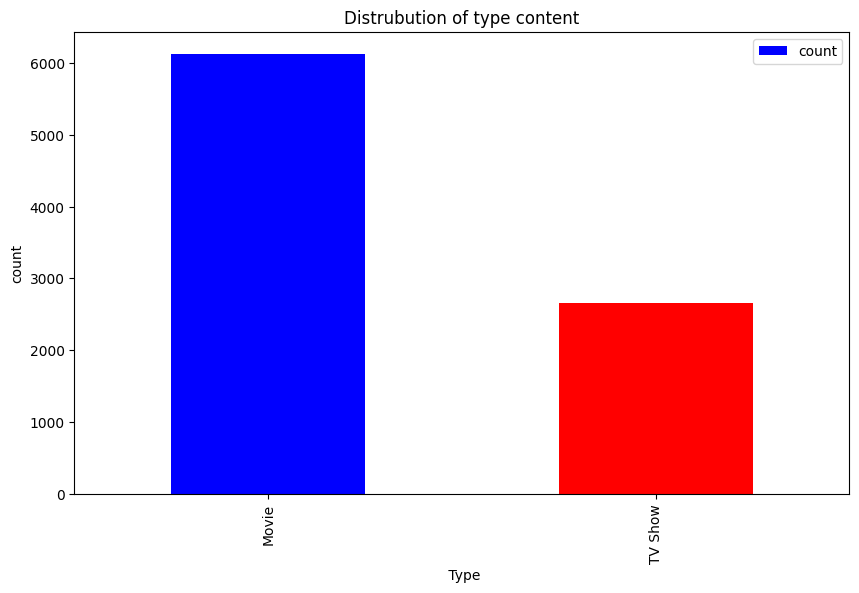

In [29]:
plt.figure(figsize=(10,6))
df['type'].value_counts().plot(kind='bar', color=['blue', 'red'])

plt.title("Distrubution of type content")
plt.xlabel(" Type")
plt.ylabel("count")
plt.legend()
plt.show()

**Insight to Write:**

- Which content type dominates Netflix?

### Task 6: Titles Released Per Year

**Plot:** Line Plot

- Count number of titles per `release_year`.
    
- Plot the trend.

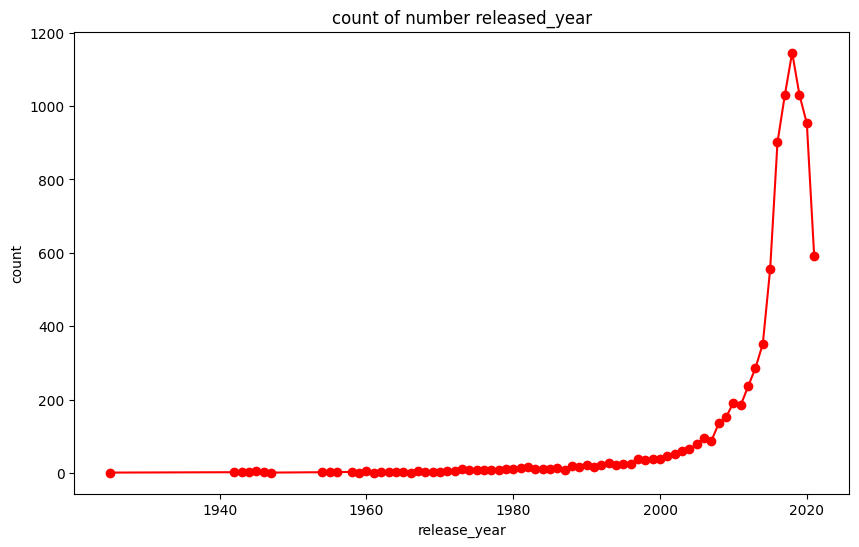

In [41]:
plt.figure(figsize=(10,6))
titles_per_year = df['release_year'].value_counts().sort_index()  # sort_index() عشان السنوات متصاعدة

plt.plot(titles_per_year.index, titles_per_year.values, marker='o', color='red')
plt.title("count of number released_year")
plt.xlabel("release_year")
plt.ylabel("count")
plt.show()

**Insight:**

- Is Netflix content increasing over time?

### Task 7: Movie Duration Distribution

**Plot:** Histogram

- Plot distribution of `duration_minutes`.
    
- Choose an appropriate number of bins.
    


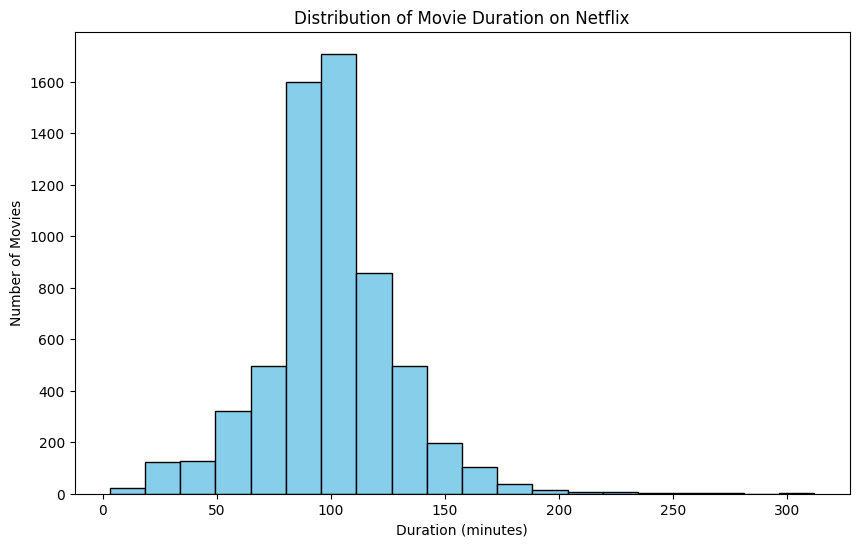

In [50]:
'''plt.figure(figsize=(10,6))
plt.hist(df['duration_minutes'],bins=10,color='white',edgecolor='red')
plt.xlabel("duration_minutes")
plt.ylabel("time ")
plt.title("Distrubution of duration_minutes ")
plt.grid(True)
plt.show()'''
plt.figure(figsize=(10,6))

# Histogra #use dropna to aviod non values in column
plt.hist(df['duration_minutes'].dropna(), bins=20, color='skyblue', edgecolor='black')  # استخدام dropna() لتجنب NaN

plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Duration on Netflix")
#plt.grid(axis='y', linestyle='--')  #   
plt.show()


**Insight:**

- Are most movies short or long?

## Part 4: Visualization Tasks (Seaborn)

### Task 8: Rating Distribution

**Plot:** Countplot

- Show distribution of ratings.

**Insight:**

- Which rating appears most frequently?

### Task 9: Top 10 Countries by Content

**Plot:** Barplot

- Find top 10 countries with most titles.
    
- Plot using Seaborn.
    

**Insight:**

- Which countries contribute most to Netflix content?
    

### Task 10: Release Year vs Type

**Plot:** Boxplot

- Compare release years for Movies vs TV Shows.
    


**Insight:**

- Which type tends to have newer content?
    


## Part 5: Advanced Visuals

### Task 11: Facet by Content Type

**Plot:** FacetGrid

- Plot distribution of release_year split by `type`.
    


### Task 12: Correlation Heatmap

**Plot:** Heatmap

- Create correlation matrix for numeric columns.
    


**Question:**

- Why does correlation look limited in this dataset?
    

## Part 6: Critical Thinking Section

Answer in words:

1. Which visualization was most useful and why?
    
2. Which plot could be misleading if misused?
    
3. How would wrong color choices affect interpretation?
    


## Bonus Challenge (Optional)

Choose ONE:

- Visualize top 5 genres.
    
- Analyze content added per year (using `year_added`).
    
- Compare movie duration across top 3 countries.
    

## Submission Requirements

- Notebook must run without errors.
    
- Each plot must include:
    
    - Title
        
    - Axis labels
        
- Each plot must have **1–2 lines of insight**.
    

### Final Note

This task focuses on **thinking like a Data Analyst**, not just drawing charts.  
The goal is to answer questions visually and clearly.